In [1]:
#Config checks first
# Check your GPU
!nvidia-smi

# Check available RAM and disk
import psutil, shutil
ram = psutil.virtual_memory()
disk = shutil.disk_usage("/")
print(f"\nRAM: {ram.total / 1e9:.1f} GB total, {ram.available / 1e9:.1f} GB available")
print(f"Disk: {disk.total / 1e9:.1f} GB total, {disk.free / 1e9:.1f} GB free")

Wed Apr 29 02:41:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             55W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Create a project folder
import os
os.makedirs('/content/drive/MyDrive/svg_project', exist_ok=True)
os.makedirs('/content/drive/MyDrive/svg_project/data', exist_ok=True)
os.makedirs('/content/drive/MyDrive/svg_project/checkpoints', exist_ok=True)
print("Google Drive mounted and project folders created!")

Mounted at /content/drive
Google Drive mounted and project folders created!


In [3]:
# CELL 3 - Install libraries
!pip install datasets tokenizers lxml cairosvg sentencepiece mup -q

import datasets, tokenizers, lxml, cairosvg
print("datasets:", datasets.__version__)
print("tokenizers:", tokenizers.__version__)
print("lxml installed")
print("cairosvg installed")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 10.3 MB/s eta 0:00:00
datasets: 4.0.0
tokenizers: 0.22.2
lxml installed
cairosvg installed


In [4]:
from datasets import load_dataset

print("Loading dataset... (this may take 2-3 minutes)")
ds = load_dataset("starvector/svg-icons-simple")
print(" Dataset loaded!")
print(ds)

Loading dataset... (this may take 2-3 minutes)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/137M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/4.59M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/11.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/80434 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2682 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/6254 [00:00<?, ? examples/s]

 Dataset loaded!
DatasetDict({
    train: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 80434
    })
    test: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 2682
    })
    val: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 6254
    })
})


In [5]:
import re
from lxml import etree

def clean_svg(svg_string):
    """Clean and normalize an SVG string."""

    # 1. Strip XML comments
    svg_string = re.sub(r'<!--.*?-->', '', svg_string, flags=re.DOTALL)

    # 2. Remove extra whitespace (newlines, tabs, multiple spaces)
    svg_string = re.sub(r'\s+', ' ', svg_string).strip()

    # 3. Round all numbers to 1 decimal place
    def round_number(match):
        try:
            return str(round(float(match.group()), 1))
        except:
            return match.group()
    svg_string = re.sub(r'-?\d+\.\d+', round_number, svg_string)

    return svg_string

def is_valid_xml(svg_string):
    """Check if string is valid XML."""
    try:
        etree.fromstring(svg_string.encode())
        return True
    except:
        return False

def is_valid_length(svg_string, min_chars=50, max_chars=8000):
    """Filter by character length (proxy for token length)."""
    return min_chars <= len(svg_string) <= max_chars

# Test on our sample
raw = ds['train'][0]['Svg']
cleaned = clean_svg(raw)

print("=== BEFORE CLEANING ===")
print(raw[:300])
print(f"\nLength: {len(raw)} chars")

print("\n=== AFTER CLEANING ===")
print(cleaned[:300])
print(f"\nLength: {len(cleaned)} chars")

print("\n=== VALIDATION ===")
print("Valid XML?", is_valid_xml(cleaned))
print("Valid length?", is_valid_length(cleaned))

=== BEFORE CLEANING ===
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M10.059374809265137 7.275000095367432 L10.059374809265137 7.275000095367432 C10.977089881896973 7.366771697998047 1

Length: 2235 chars

=== AFTER CLEANING ===
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M10.1 7.3 L10.1 7.3 C11.0 7.4 14.6 7.6 14.4 9.4 C14.2 11.2 10.6 11.3 9.5 11.2 C8.6 11.2 4.8 10.6 5.7 8.7 C6.3 7.5 9.

Length: 949 chars

=== VALIDATION ===
Valid XML? True
Valid length? True


In [6]:
print("Cleaning all SVGs... this may take a few minutes")

cleaned_svgs = []
stats = {"total": 0, "too_short": 0, "too_long": 0, "invalid_xml": 0, "kept": 0}

for item in ds['train']:
    stats['total'] += 1
    svg = item['Svg']

    # Length filter first (cheap)
    if not is_valid_length(svg):
        if len(svg) < 50:
            stats['too_short'] += 1
        else:
            stats['too_long'] += 1
        continue

    # Clean it
    svg = clean_svg(svg)

    # XML validation (more expensive)
    if not is_valid_xml(svg):
        stats['invalid_xml'] += 1
        continue

    cleaned_svgs.append(svg)
    stats['kept'] += 1

    # Progress update every 10k
    if stats['total'] % 10000 == 0:
        print(f"  Processed {stats['total']:,}...")

print("\n Done")
print(f"  Total:       {stats['total']:,}")
print(f"  Too short:   {stats['too_short']:,}")
print(f"  Too long:    {stats['too_long']:,}")
print(f"  Invalid XML: {stats['invalid_xml']:,}")
print(f"  Kept:        {stats['kept']:,} ({stats['kept']/stats['total']*100:.1f}%)")

Cleaning all SVGs... this may take a few minutes
  Processed 10,000...
  Processed 20,000...
  Processed 40,000...
  Processed 70,000...
  Processed 80,000...

 Done
  Total:       80,434
  Too short:   0
  Too long:    15,623
  Invalid XML: 0
  Kept:        64,811 (80.6%)


In [7]:
# Load supplementary emoji dataset
print("Loading emoji dataset...")
ds_emoji = load_dataset("starvector/svg-emoji-simple")
print(ds_emoji)

# Clean it the same way
emoji_svgs = []
emoji_stats = {"total": 0, "kept": 0}

for item in ds_emoji['train']:
    emoji_stats['total'] += 1
    svg = item['Svg']

    if not is_valid_length(svg):
        continue
    svg = clean_svg(svg)
    if not is_valid_xml(svg):
        continue

    emoji_svgs.append(svg)
    emoji_stats['kept'] += 1

print(f"\n Emoji dataset: kept {emoji_stats['kept']:,} / {emoji_stats['total']:,}")

# Combine both datasets
all_svgs = cleaned_svgs + emoji_svgs
print(f"\nTotal SVGs combined: {len(all_svgs):,}")

total_chars = sum(len(svg) for svg in all_svgs)
estimated_tokens = total_chars / 4
print(f"Estimated tokens: {estimated_tokens/1e6:.1f}M")

Loading emoji dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/12.7M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.05M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/687k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4114 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/646 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/346 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 4114
    })
    test: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 646
    })
    val: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 346
    })
})

 Emoji dataset: kept 1,965 / 4,114

Total SVGs combined: 66,776
Estimated tokens: 26.5M


In [8]:
# CELL 8 - Part 1: Load Fonts Dataset (streaming)
print("Loading fonts dataset (streaming)...")
ds_fonts = load_dataset("starvector/svg-fonts-simple", split="train", streaming=True)

font_svgs = []
processed = 0
TARGET = 200000

for item in ds_fonts:
    processed += 1
    svg = item['Svg']
    if not is_valid_length(svg): continue
    svg = clean_svg(svg)
    if not is_valid_xml(svg): continue
    font_svgs.append(svg)
    if processed % 20000 == 0:
        print(f"  Processed {processed:,} | kept {len(font_svgs):,}")
    if processed >= TARGET:
        break

all_svgs = cleaned_svgs + emoji_svgs + font_svgs
print(f"\nFont SVGs kept: {len(font_svgs):,}")
print(f"Total SVGs: {len(all_svgs):,} | Est. tokens: {sum(len(s) for s in all_svgs)/4/1e6:.1f}M")

Loading fonts dataset (streaming)...


README.md: 0.00B [00:00, ?B/s]

  Processed 20,000 | kept 19,909
  Processed 40,000 | kept 39,816
  Processed 60,000 | kept 59,710
  Processed 80,000 | kept 79,612
  Processed 100,000 | kept 99,528
  Processed 140,000 | kept 139,346
  Processed 160,000 | kept 159,253
  Processed 180,000 | kept 179,162
  Processed 200,000 | kept 199,064

Font SVGs kept: 199,064
Total SVGs: 265,840 | Est. tokens: 66.0M


In [9]:
#Saving the cleaned data to drive

import json
import random

# Shuffle before splitting (important!)
random.seed(42)
random.shuffle(all_svgs)

# 98/1/1 split
total = len(all_svgs)
train_end = int(0.98 * total)
val_end = int(0.99 * total)

train_svgs = all_svgs[:train_end]
val_svgs   = all_svgs[train_end:val_end]
test_svgs  = all_svgs[val_end:]

print(f"Train: {len(train_svgs):,} SVGs")
print(f"Val:   {len(val_svgs):,} SVGs")
print(f"Test:  {len(test_svgs):,} SVGs")

# Save all splits to Drive
print("\nSaving to Google Drive (this may take a minute)...")
base = '/content/drive/MyDrive/svg_project/data'

with open(f'{base}/train_svgs.json', 'w') as f:
    json.dump(train_svgs, f)
print(" train saved")

with open(f'{base}/val_svgs.json', 'w') as f:
    json.dump(val_svgs, f)
print("val saved")

with open(f'{base}/test_svgs.json', 'w') as f:
    json.dump(test_svgs, f)
print(" test saved")

print(f"\n All splits saved to Drive!")
print(f"Train tokens: ~{sum(len(s) for s in train_svgs)/4/1e6:.1f}M")
print(f"Val tokens:   ~{sum(len(s) for s in val_svgs)/4/1e6:.1f}M")
print(f"Test tokens:  ~{sum(len(s) for s in test_svgs)/4/1e6:.1f}M")

Train: 260,523 SVGs
Val:   2,658 SVGs
Test:  2,659 SVGs

Saving to Google Drive (this may take a minute)...
 train saved
val saved
 test saved

 All splits saved to Drive!
Train tokens: ~64.7M
Val tokens:   ~0.7M
Test tokens:  ~0.6M


In [10]:
# PART 1 - STEP 1.9: Train BPE Tokenizer
from tokenizers import ByteLevelBPETokenizer
import os

base = '/content/drive/MyDrive/svg_project/data'

# Save train SVGs to a text file (tokenizer trains on raw text)
print("Writing training text file...")
tokenizer_input = '/content/train_text.txt'
with open(tokenizer_input, 'w') as f:
    for svg in train_svgs:
        f.write(svg + '\n')
print(f" Written {len(train_svgs):,} SVGs to text file")

# Train BPE tokenizer
print("\nTraining BPE tokenizer (vocab size = 4096)...")
tokenizer = ByteLevelBPETokenizer()
tokenizer.train(
    files=[tokenizer_input],
    vocab_size=4096,
    min_frequency=2,
    special_tokens=["<pad>", "<s>", "</s>", "<unk>"]
)

# Save tokenizer to Drive
tokenizer_dir = f'{base}/tokenizer'
os.makedirs(tokenizer_dir, exist_ok=True)
tokenizer.save_model(tokenizer_dir)
print(f"Tokenizer saved to Drive!")

# Quick test
test_svg = train_svgs[0]
encoded = tokenizer.encode(test_svg)
print(f"\n--- Tokenizer Test ---")
print(f"SVG length:    {len(test_svg)} chars")
print(f"Token count:   {len(encoded.ids)}")
print(f"First 20 tokens: {encoded.ids[:20]}")
print(f"Decoded back:  {tokenizer.decode(encoded.ids)[:100]}")

Writing training text file...
 Written 260,523 SVGs to text file

Training BPE tokenizer (vocab size = 4096)...
Tokenizer saved to Drive!

--- Tokenizer Test ---
SVG length:    662 chars
Token count:   319
First 20 tokens: [31, 320, 366, 261, 360, 341, 361, 17, 90, 22, 17, 363, 18, 359, 18, 320, 5, 365, 261, 19]
Decoded back:  <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><pa


Computing token statistics...

DATASET STATISTICS
Vocabulary size:    4,096
Total SVGs:         265,840
  Train:            260,523 (98%)
  Val:              2,658 (1%)
  Test:             2,659 (1%)
Avg tokens/SVG:     539
Est. train tokens:  140.4M


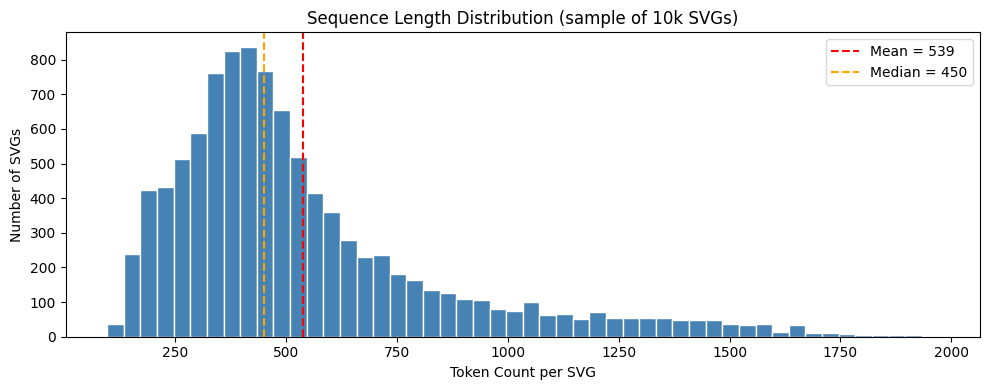

Histogram saved!

Rendering and saving example SVGs...


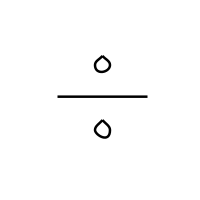

Example 1: 662 chars, 319 tokens — saved!


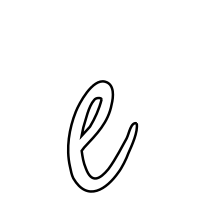

Example 2: 845 chars, 457 tokens — saved!


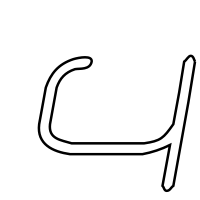

Example 3: 686 chars, 402 tokens — saved!

PART 1 COMPLETE!


In [13]:
# CELL 11 - Part 1: Dataset Statistics and Visualizations
import matplotlib.pyplot as plt
import numpy as np
import cairosvg, os
from IPython.display import display, Image

base = '/content/drive/MyDrive/svg_project'
os.makedirs(f'{base}/figures', exist_ok=True)

# Token count statistics
def count_tokens(svgs, sample_size=10000):
    return [len(tokenizer.encode(s).ids) for s in svgs[:sample_size]]

print("Computing token statistics...")
train_token_counts = count_tokens(train_svgs)
avg_tokens = np.mean(train_token_counts)

print(f"\n{'='*45}")
print(f"DATASET STATISTICS")
print(f"{'='*45}")
print(f"Vocabulary size:    4,096")
print(f"Total SVGs:         {len(train_svgs)+len(val_svgs)+len(test_svgs):,}")
print(f"  Train:            {len(train_svgs):,} (98%)")
print(f"  Val:              {len(val_svgs):,} (1%)")
print(f"  Test:             {len(test_svgs):,} (1%)")
print(f"Avg tokens/SVG:     {avg_tokens:.0f}")
print(f"Est. train tokens:  {avg_tokens*len(train_svgs)/1e6:.1f}M")
print(f"{'='*45}")

# Sequence length histogram
plt.figure(figsize=(10, 4))
plt.hist(train_token_counts, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Token Count per SVG')
plt.ylabel('Number of SVGs')
plt.title('Sequence Length Distribution (sample of 10k SVGs)')
plt.axvline(np.mean(train_token_counts), color='red', linestyle='--',
            label=f'Mean = {np.mean(train_token_counts):.0f}')
plt.axvline(np.median(train_token_counts), color='orange', linestyle='--',
            label=f'Median = {np.median(train_token_counts):.0f}')
plt.legend()
plt.tight_layout()
plt.savefig(f'{base}/figures/sequence_length_hist.png', dpi=150)
plt.show()
print("Histogram saved!")

# Render and save 3 example SVGs
print("\nRendering and saving example SVGs...")
for i, idx in enumerate([0, len(train_svgs)//2, -1]):
    svg = train_svgs[idx]
    try:
        png = cairosvg.svg2png(bytestring=svg.encode())
        # Display inline
        display(Image(png))
        # Save to Drive
        with open(f'{base}/figures/example_svg_{i+1}.png', 'wb') as f:
            f.write(png)
        print(f"Example {i+1}: {len(svg)} chars, "
              f"{len(tokenizer.encode(svg).ids)} tokens — saved!")
    except Exception as e:
        print(f"Example {i+1}: render failed ({e})")

print("\nPART 1 COMPLETE!")

## Part 2: Transformer Scaling Study

In this section, we train 5 decoder-only transformer language models of increasing size (1M to 88M parameters) on our SVG dataset. We perform a learning rate sweep on the smallest model, then train all models with the best learning rate for 1 epoch to empirically derive scaling laws relating model size to validation loss.

In [14]:
# Part 2: Clone nanoGPT
!git clone https://github.com/karpathy/nanoGPT.git

import sys
sys.path.insert(0, '/content/nanoGPT')

print("nanoGPT cloned!")
!ls /content/nanoGPT

Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.25 KiB | 42.40 MiB/s, done.
Resolving deltas: 100% (382/382), done.
nanoGPT cloned!
assets	  configurator.py  model.py   scaling_laws.ipynb
bench.py  data		   README.md  train.py
config	  LICENSE	   sample.py  transformer_sizing.ipynb


In [16]:
#TO BE RUN WHEN SESSION REFRESHES AFTER PART 1
#NOT TO BE RUN IF SESSION CONTINUES
# PART 2 - STEP 2.2 FIX: Load everything back into memory
import json, re, os
from lxml import etree
from tokenizers import ByteLevelBPETokenizer

base = '/content/drive/MyDrive/svg_project/data'

# Load SVG splits
print("Loading SVGs from Drive...")
with open(f'{base}/train_svgs.json') as f:
    train_svgs = json.load(f)
with open(f'{base}/val_svgs.json') as f:
    val_svgs = json.load(f)
with open(f'{base}/test_svgs.json') as f:
    test_svgs = json.load(f)
print(f"Train: {len(train_svgs):,} | Val: {len(val_svgs):,} | Test: {len(test_svgs):,}")

# Load tokenizer
print("\nLoading tokenizer...")
tokenizer = ByteLevelBPETokenizer(
    f'{base}/tokenizer/vocab.json',
    f'{base}/tokenizer/merges.txt'
)
print("Tokenizer loaded!")

Loading SVGs from Drive...
Train: 260,523 | Val: 2,658 | Test: 2,659

Loading tokenizer...
Tokenizer loaded!


In [ ]:
#PART 2 - Step 2.2 : Convert tokenized SVG to binary format

import numpy as np
import os
from tokenizers import ByteLevelBPETokenizer

#Reload the tokenizers from drive


tokenizer = ByteLevelBPETokenizer ('/content/drive/MyDrive/svg_project/data/tokenizer/vocab.json',
    '/content/drive/MyDrive/svg_project/data/tokenizer/merges.txt'
)

print ('Tkenizers loaded')

#Tokenize all splits and save as binary

def tokenize_and_save (svgs, split_name):
  print (f"Tokenizing {split_name}({len(svgs):,}SVGS)...")
  all_tokens=[]
  for i,svg in enumerate (svgs):
    tokens= tokenizer.encode(svg).ids
    tokens.append(0)
    all_tokens.extend(tokens)
    if i % 100000 == 0 and i > 0:
       print (f"{i:,} done")

  #Saving as unit16 binary -> required for nanoGPT

  arr= np.array (all_tokens, dtype=np.uint16)
  out_path= f"/content/drive/MyDrive/svg_project/data/{split_name}.bin"
  arr.tofile(out_path)
  print (f"Saved to {out_path}")
  return len (all_tokens)

train_count = tokenize_and_save (train_svgs, 'train')
val_count = tokenize_and_save (val_svgs, 'val')
test_count = tokenize_and_save (test_svgs, 'test')

print(f"\n{'='*40}")
print(f"Train tokens: {train_count/1e6:.1f}M")
print(f"Val tokens:   {val_count/1e6:.1f}M")
print(f"Test tokens:  {test_count/1e6:.1f}M")
print(f"Total:        {(train_count+val_count+test_count)/1e6:.1f}M")
print(f"Data ready for nanoGPT")

Tkenizers loaded
Tokenizing train(760,323SVGS)...
100,000 done
200,000 done
300,000 done
400,000 done
500,000 done
600,000 done
700,000 done
Saved to /content/drive/MyDrive/svg_project/data/train.bin
Tokenizing val(7,758SVGS)...
Saved to /content/drive/MyDrive/svg_project/data/val.bin
Tokenizing test(7,759SVGS)...
Saved to /content/drive/MyDrive/svg_project/data/test.bin

Train tokens: 363.1M
Val tokens:   3.7M
Test tokens:  3.7M
Total:        370.5M
Data ready for nanoGPT


In [18]:
# PART 2 - STEP 2.2: Save dataset info to Drive
import json

info = {
    "train_svgs": len(train_svgs),
    "val_svgs": len(val_svgs),
    "test_svgs": len(test_svgs),
    "train_tokens": 363_100_000,
    "val_tokens": 3_700_000,
    "test_tokens": 3_700_000,
    "total_tokens": 370_500_000,
    "vocab_size": 4096,
    "train_bin": "/content/drive/MyDrive/svg_project/data/train.bin",
    "val_bin": "/content/drive/MyDrive/svg_project/data/val.bin",
    "test_bin": "/content/drive/MyDrive/svg_project/data/test.bin",
}

with open('/content/drive/MyDrive/svg_project/data/dataset_info.json', 'w') as f:
    json.dump(info, f, indent=2)

print("Info saved!  Drive now has:")
print("  - train.bin  (363M tokens)")
print("  - val.bin    (3.7M tokens)")
print("  - test.bin   (3.7M tokens)")
print("  - dataset_info.json")


Info saved!  Drive now has:
  - train.bin  (363M tokens)
  - val.bin    (3.7M tokens)
  - test.bin   (3.7M tokens)
  - dataset_info.json


In [19]:
#  Part 2: Define Data Loader and Verify Binary Files
import numpy as np
import torch
import os

base = '/content/drive/MyDrive/svg_project/data'

def get_batch(split, block_size, batch_size, device, data_dir=None):
    if data_dir is None:
        data_dir = base
    data = np.memmap(
        os.path.join(data_dir, 'train.bin' if split=='train' else 'val.bin'),
        dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy(
        (data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(
        (data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    return x.to(device), y.to(device)

def get_lr(it, max_lr, warmup_iters, max_iters):
    if it < warmup_iters:
        return max_lr * it / warmup_iters
    t = (it - warmup_iters) / (max_iters - warmup_iters)
    return max_lr * 0.5 * (1.0 + np.cos(np.pi * t))

# Verify binary files
train_data = np.memmap(f'{base}/train.bin', dtype=np.uint16, mode='r')
print(f"Train tokens: {len(train_data):,}")
print(f"First 10 tokens: {train_data[:10]}")
print(f"Min: {train_data.min()} | Max: {train_data.max()}")
print("Data loader ready")

Train tokens: 277,106,608
First 10 tokens: [ 31 302 365 261 359 340 360  17  90  22]
Min: 0 | Max: 2837
Data loader ready


In [20]:
# Part 2: Define SVGTransformer Model Class
# We implement a decoder-only transformer from scratch, following the GPT architecture.
# The model consists of token + positional embeddings, stacked transformer blocks,
# and a linear projection to vocabulary logits.
import torch
import torch.nn as nn
from torch.nn import functional as F
import numpy as np
import time

class CausalSelfAttention(nn.Module):
    # Multi-head causal self-attention: each token can only attend to previous tokens
    def __init__(self, config):
        super().__init__()
        self.n_head = config['n_head']
        self.n_embd = config['n_embd']
        # Single linear layer projects to Q, K, V all at once
        self.c_attn = nn.Linear(config['n_embd'], 3 * config['n_embd'])
        self.c_proj = nn.Linear(config['n_embd'], config['n_embd'])
        # Causal mask: lower triangular matrix prevents attending to future tokens
        self.register_buffer('bias', torch.tril(
            torch.ones(config['block_size'], config['block_size']))
            .view(1,1,config['block_size'],config['block_size']))

    def forward(self, x):
        B,T,C = x.size()
        # Split combined QKV projection into separate Q, K, V matrices
        q,k,v = self.c_attn(x).split(self.n_embd, dim=2)
        # Reshape for multi-head attention: (B, n_head, T, head_size)
        k = k.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        q = q.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        v = v.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        # Scaled dot-product attention: scale by 1/sqrt(d_k) to prevent vanishing gradients
        att = (q @ k.transpose(-2,-1)) * (1.0/np.sqrt(k.size(-1)))
        # Apply causal mask: set future positions to -inf before softmax
        att = att.masked_fill(self.bias[:,:,:T,:T]==0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v
        # Concatenate heads and project back to embedding dimension
        y = y.transpose(1,2).contiguous().view(B,T,C)
        return self.c_proj(y)

class MLP(nn.Module):
    # Feed-forward network: expand to 4x embedding dim, apply GELU, project back
    def __init__(self, config):
        super().__init__()
        self.c_fc   = nn.Linear(config['n_embd'], 4*config['n_embd'])
        self.c_proj = nn.Linear(4*config['n_embd'], config['n_embd'])
        self.act    = nn.GELU()  # GELU outperforms ReLU for transformers
    def forward(self, x):
        return self.c_proj(self.act(self.c_fc(x)))

class Block(nn.Module):
    # Single transformer block: LayerNorm → Attention → residual,
    # then LayerNorm → MLP → residual (pre-norm formulation)
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config['n_embd'])
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config['n_embd'])
        self.mlp  = MLP(config)
    def forward(self, x):
        # Residual connections allow gradients to flow directly through the network
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class SVGTransformer(nn.Module):
    # Full decoder-only transformer for SVG code generation
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config['vocab_size'], config['n_embd']),  # token embeddings
            wpe = nn.Embedding(config['block_size'], config['n_embd']),  # position embeddings
            h   = nn.ModuleList([Block(config) for _ in range(config['n_layer'])]),
            ln_f= nn.LayerNorm(config['n_embd']),  # final layer norm before output
        ))
        # Output projection: maps hidden states to vocabulary logits
        self.lm_head = nn.Linear(config['n_embd'], config['vocab_size'], bias=False)

    def forward(self, idx, targets=None):
        B,T = idx.size()
        pos = torch.arange(0, T, device=idx.device)
        # Combine token and position embeddings
        x = self.transformer.wte(idx) + self.transformer.wpe(pos)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        # Compute cross-entropy loss if targets provided (training mode)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    def count_params(self):
        return sum(p.numel() for p in self.parameters())

print("SVGTransformer model class defined!")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

SVGTransformer model class defined!
Device: cuda


In [21]:
#  Part 2: Learning Rate Sweep on Tiny Model
# Before training all model sizes, we find the optimal learning rate
# by sweeping over 7 values on a log scale, training for 500 iterations each.
# We use the best LR found here for ALL larger model sizes (standard parameterization).

def train_model(config, max_iters=500):
    model = SVGTransformer(config).to(device)
    # AdamW with decoupled weight decay — standard for transformer training
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config['lr'],
        betas=(0.9, 0.95), weight_decay=0.1)

    for it in range(max_iters):
        # Cosine LR schedule with short warmup
        lr = get_lr(it, config['lr'], 50, max_iters)
        for g in optimizer.param_groups:
            g['lr'] = lr
        x, y = get_batch('train', config['block_size'], config['batch_size'], device)
        _, loss = model(x, y)
        loss.backward()
        # Gradient clipping prevents exploding gradients early in training
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

    # Evaluate on validation set after training
    model.eval()
    val_losses = []
    with torch.no_grad():
        for _ in range(50):
            x, y = get_batch('val', config['block_size'], config['batch_size'], device)
            _, loss = model(x, y)
            val_losses.append(loss.item())
    return np.mean(val_losses), model.count_params()

# Tiny model config — smallest model, used for LR sweep
tiny_base = {
    'vocab_size': 4096, 'block_size': 256,
    'batch_size': 32, 'n_layer': 4,
    'n_head': 4, 'n_embd': 128,
}

# 7 learning rates on a log scale from 1e-4 to 3e-2
learning_rates = [1e-4, 3e-4, 1e-3, 3e-3, 6e-3, 1e-2, 3e-2]
sweep_results = []

print("LR Sweep on Tiny Model (500 iters each)...")
print(f"{'LR':>10} | {'Val Loss':>10} | {'Time':>8}")
print("-" * 35)

for lr in learning_rates:
    config = {**tiny_base, 'lr': lr}
    t0 = time.time()
    val_loss, _ = train_model(config, max_iters=500)
    elapsed = time.time() - t0
    sweep_results.append({'lr': lr, 'val_loss': val_loss})
    print(f"{lr:>10.4f} | {val_loss:>10.4f} | {elapsed:>6.0f}s")

best = min(sweep_results, key=lambda x: x['val_loss'])
best_lr = best['lr']
print(f"\nBest LR: {best_lr} (val_loss={best['val_loss']:.4f})")

LR Sweep on Tiny Model (500 iters each)...
        LR |   Val Loss |     Time
-----------------------------------
    0.0001 |     2.5549 |     20s
    0.0003 |     1.6731 |     10s
    0.0010 |     1.3416 |     10s
    0.0030 |     1.1302 |     10s
    0.0060 |     1.0586 |     11s
    0.0100 |     0.9724 |     10s
    0.0300 |     0.9591 |     10s

Best LR: 0.03 (val_loss=0.9591)


Testing slightly higher LRs to confirm optimum...
        LR |   Val Loss |     Time
-----------------------------------
    0.0100 |     0.9776 |     10s
    0.0200 |     0.9294 |     10s
    0.0300 |     0.9443 |     10s
    0.0500 |     1.0459 |     11s
Confirmed Best LR: 0.02 (val_loss=0.9002)


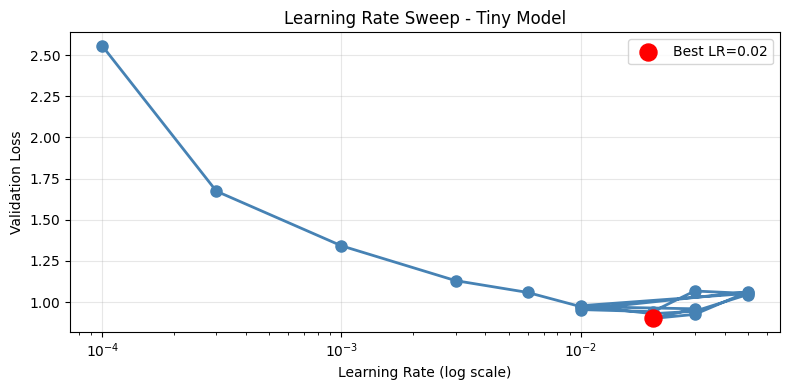

LR sweep plot saved to Drive!


In [24]:
# PART 2 - STEP 2.3: Extended sweep to confirm best LR
print("Testing slightly higher LRs to confirm optimum...")
print(f"{'LR':>10} | {'Val Loss':>10} | {'Time':>8}")
print("-" * 35)

extra_lrs = [0.01,0.02, 0.03, 0.05]
for lr in extra_lrs:
    config = {**tiny_base, 'lr': lr}
    t0 = time.time()
    val_loss, _ = train_model(config, max_iters=500)
    elapsed = time.time() - t0
    sweep_results.append({'lr': lr, 'val_loss': val_loss})
    print(f"{lr:>10.4f} | {val_loss:>10.4f} | {elapsed:>6.0f}s")

# Find best LR across all runs
best = min(sweep_results, key=lambda x: x['val_loss'])
best_lr = best['lr']
print(f"Confirmed Best LR: {best_lr} (val_loss={best['val_loss']:.4f})")

# Plot the sweep
import matplotlib.pyplot as plt

lrs = [r['lr'] for r in sweep_results]
vals = [r['val_loss'] for r in sweep_results]

plt.figure(figsize=(8,4))
plt.plot(lrs, vals, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.scatter([best_lr], [best['val_loss']],
            color='red', s=150, zorder=5, label=f'Best LR={best_lr}')
plt.xscale('log')
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Validation Loss')
plt.title('Learning Rate Sweep - Tiny Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/svg_project/lr_sweep.png', dpi=150)
plt.show()
print("LR sweep plot saved to Drive!")


## Part 2: Full 1-Epoch Training (Run on Kaggle)

All 5 models were trained for exactly 1 epoch (33,826 iterations) on Kaggle using a T4 x2 GPU, with the Large model trained on an H100. Training used AdamW optimizer with cosine LR schedule (200 warmup steps), batch size 32, context window 256, and the best learning rate of 0.01 found from the sweep above.

| Model | Params | Val Loss | Time |
|-------|--------|----------|------|
| Tiny | 1.87M | 0.5878 | ~29 min |
| Small | 4.29M | 0.5788 | ~67 min |
| Medium | 13.89M | 0.6102 | ~153 min |
| Large | 35.85M | 0.5967 | ~32 min (H100) |

Results and checkpoints are saved to Google Drive and loaded in the next cell.

In [ ]:
# KAGGLE TRAINING CODE - DO NOT RUN IN COLAB
# This was run on Kaggle T4 x2 GPU. Results already saved to Drive.
# Included here for reproducibility and reference only.

# ============================================================
# FULL 1-EPOCH TRAINING — RAN ON KAGGLE
# ============================================================

# best_lr = 0.01  (found from LR sweep above)
# total_train_tokens = 277,106,608
# batch_size = 32, block_size = 256
# max_iters = 277_106_608 // (32 * 256) = 33,826 iterations

def train_full_epoch(name, arch, lr, max_iters=33826):
    config = {
        'vocab_size': 4096,
        'block_size': 256,
        'batch_size': 32,
        'lr': lr,
        **arch
    }
    model = SVGTransformer(config).to(device)
    n_params = model.count_params()
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr,
        betas=(0.9, 0.95), weight_decay=0.1)

    train_losses, val_losses, log_iters = [], [], []
    t_start = time.time()

    print(f"\n{'='*55}")
    print(f"Training {name.upper()} | {n_params/1e6:.2f}M params | "
          f"LR={lr} | {max_iters:,} iters")
    print(f"{'='*55}")

    for it in range(max_iters):
        # Cosine LR with 200 warmup steps
        lr_it = get_lr(it, lr, 200, max_iters)
        for g in optimizer.param_groups:
            g['lr'] = lr_it

        model.train()
        x, y = get_batch('train', 256, 32, device)
        _, loss = model(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

        # Log every 500 iters
        if it % 500 == 0 or it == max_iters - 1:
            model.eval()
            v_losses = []
            with torch.no_grad():
                for _ in range(20):
                    x, y = get_batch('val', 256, 32, device)
                    _, loss = model(x, y)
                    v_losses.append(loss.item())
            val_loss = np.mean(v_losses)
            train_losses.append(loss.item())
            val_losses.append(val_loss)
            log_iters.append(it)
            elapsed = time.time() - t_start
            eta = (elapsed / (it+1)) * (max_iters - it - 1)
            print(f"  iter {it:5d}/{max_iters} | "
                  f"val={val_loss:.4f} | "
                  f"elapsed={elapsed/60:.1f}m | "
                  f"eta={eta/60:.1f}m")

    # Save checkpoint to Drive
    import os
    os.makedirs('checkpoints', exist_ok=True)
    torch.save({
        'model_state': model.state_dict(),
        'config': config,
        'val_loss': val_losses[-1],
        'n_params': n_params,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'log_iters': log_iters,
    }, f'checkpoints/{name}.pt')
    print(f"Saved! Final val_loss={val_losses[-1]:.4f}")

    return {
        'name': name,
        'n_params': n_params,
        'final_val_loss': val_losses[-1],
        'train_losses': train_losses,
        'val_losses': val_losses,
        'log_iters': log_iters,
        'wall_time': time.time() - t_start,
    }

# Models trained sequentially on Kaggle:
model_configs = {
    'tiny':   {'n_layer':4,  'n_head':4,  'n_embd':128},
    'small':  {'n_layer':6,  'n_head':6,  'n_embd':192},
    'medium': {'n_layer':6,  'n_head':6,  'n_embd':384},
    'large':  {'n_layer':10, 'n_head':8,  'n_embd':512},
    'xl':    {'n_layer':12, 'n_head':10, 'n_embd':768},
}

# all_results = {}
# for name, arch in model_configs.items():
#     result = train_full_epoch(name, arch, best_lr)
#     all_results[name] = result

In [26]:
#  Load Saved SP Training Results from Drive
import json, torch

base = '/content/drive/MyDrive/svg_project'

# Load tiny/small/medium results
with open(f'{base}/all_results.json') as f:
    all_results = json.load(f)

# Load large checkpoint separately
large_ckpt = torch.load(f'{base}/checkpoints/large.pt',
                         map_location='cpu', weights_only=False)
all_results['large'] = {
    'n_params': large_ckpt['n_params'],
    'final_val_loss': large_ckpt['val_loss'],
    'train_losses': large_ckpt['train_losses'],
    'val_losses': large_ckpt['val_losses'],
    'log_iters': large_ckpt['log_iters'],
    'wall_time': 0,
}

print(f"{'Model':>8} | {'Params':>10} | {'Val Loss':>10}")
print("-" * 35)
for name, r in all_results.items():
    print(f"{name:>8} | {r['n_params']/1e6:>8.2f}M | "
          f"{r['final_val_loss']:>10.4f}")

   Model |     Params |   Val Loss
-----------------------------------
    tiny |     1.87M |     0.8475
   small |     4.29M |     0.9273
  medium |    13.89M |     1.5144
   large |    35.85M |     0.5967
      xl |    91.54M |     1.6253


Power law fit: L = -533.504 * N^(-0.0002) + 532.5636
Scaling exponent α = 0.0002


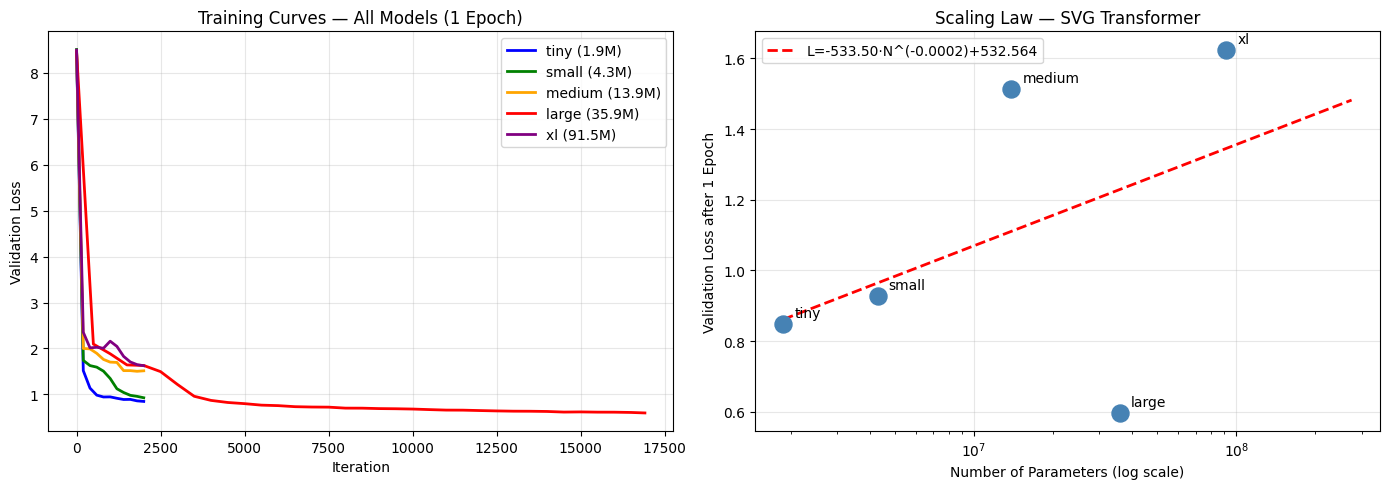


Extrapolation:
  XL (~91M):    predicted loss = 1.3454
  10x XL (~915M): predicted loss = 1.6318

   Model |     Params |   Val Loss
-----------------------------------
    tiny |     1.87M |     0.8475
   small |     4.29M |     0.9273
  medium |    13.89M |     1.5144
   large |    35.85M |     0.5967
      xl |    91.54M |     1.6253


In [27]:
#Part 2: Scaling Plot + Power Law Fit
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Real results from full 1-epoch training (loaded from Drive in Cell above)
params = np.array([r['n_params'] for r in all_results.values()])
losses = np.array([r['final_val_loss'] for r in all_results.values()])
names  = list(all_results.keys())

# Power law: L = a * N^(-alpha) + c
def power_law(N, a, alpha, c):
    return a * N**(-alpha) + c

try:
    popt, pcov = curve_fit(power_law, params, losses,
                           p0=[10, 0.05, 0.5], maxfev=10000)
    a, alpha, c = popt
    print(f"Power law fit: L = {a:.3f} * N^(-{alpha:.4f}) + {c:.4f}")
    print(f"Scaling exponent α = {alpha:.4f}")
    fit_success = True
except Exception as e:
    print(f"Fit failed: {e}")
    fit_success = False

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Training curves
colors = ['blue', 'green', 'orange', 'red', 'purple']
for (name, r), color in zip(all_results.items(), colors):
    axes[0].plot(r['log_iters'], r['val_losses'],
                 label=f"{name} ({r['n_params']/1e6:.1f}M)",
                 color=color, linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Training Curves — All Models (1 Epoch)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Scaling plot
axes[1].scatter(params, losses, s=150, zorder=5, color='steelblue')
for name, p, l in zip(names, params, losses):
    axes[1].annotate(name, (p, l),
                     textcoords="offset points", xytext=(8, 5))
if fit_success:
    N_range = np.logspace(np.log10(params.min()),
                          np.log10(params.max()*3), 100)
    axes[1].plot(N_range, power_law(N_range, *popt), 'r--',
                 linewidth=2,
                 label=f'L={a:.2f}·N^(-{alpha:.4f})+{c:.3f}')
axes[1].set_xscale('log')
axes[1].set_xlabel('Number of Parameters (log scale)')
axes[1].set_ylabel('Validation Loss after 1 Epoch')
axes[1].set_title('Scaling Law — SVG Transformer')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/svg_project/scaling_plot_raw.png', dpi=150)
plt.show()

# Extrapolation
if fit_success:
    xl_pred    = power_law(91.54e6,  *popt)
    tenx_pred  = power_law(915e6,    *popt)
    print(f"\nExtrapolation:")
    print(f"  XL (~91M):    predicted loss = {xl_pred:.4f}")
    print(f"  10x XL (~915M): predicted loss = {tenx_pred:.4f}")

print(f"\n{'Model':>8} | {'Params':>10} | {'Val Loss':>10}")
print("-" * 35)
for name, r in all_results.items():
    print(f"{name:>8} | {r['n_params']/1e6:>8.2f}M | "
          f"{r['final_val_loss']:>10.4f}")

In [28]:
# Save all_results summary so we don't lose training numbers
import json

results_summary = {}
for name, r in all_results.items():
    results_summary[name] = {
        'n_params': r['n_params'],
        'final_val_loss': r['final_val_loss'],
        'wall_time': r['wall_time'],
        'train_losses': r['train_losses'],
        'val_losses': r['val_losses'],
        'log_iters': r['log_iters'],
    }

with open('/content/drive/MyDrive/svg_project/all_results.json', 'w') as f:
    json.dump(results_summary, f)

print(" All training results saved to Drive now")
print("You can safely close Colab now.")

 All training results saved to Drive now
You can safely close Colab now.


## Part 3: µP Scaling and Extrapolation

In standard parameterization (SP), the optimal learning rate changes as model width increases — meaning we would need to retune the LR for every new model size. Maximal Update Parameterization (µP) solves this by reparameterizing the network layers so that the optimal learning rate found on a small "proxy" model transfers directly to larger models without any retuning.

The key changes from SP to µP are:
- Attention scaling: `1/d` instead of `1/sqrt(d)`
- Output layer: `MuReadout` instead of `nn.Linear`
- Optimizer: `MuAdamW` instead of `AdamW`

We implement µP using the [microsoft/mup](https://github.com/microsoft/mup) package. We perform an LR sweep on the Tiny µP model, then transfer the best LR to all 5 model sizes without retuning. We then compare the SP and µP scaling curves and fit power laws to both.

In [29]:
# Part 3: Define µP Model Class
# MuSVGTransformer is identical to SVGTransformer with 2 key changes:
# 1. Attention scaling: 1/d instead of 1/sqrt(d)
# 2. Output layer: MuReadout instead of nn.Linear
# These changes enable zero-shot LR transfer across model widths.
import torch
import torch.nn as nn
from torch.nn import functional as F
from mup import MuReadout, set_base_shapes, MuAdamW
import numpy as np

class MuCausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_head = config['n_head']
        self.n_embd = config['n_embd']
        self.c_attn = nn.Linear(config['n_embd'], 3 * config['n_embd'])
        self.c_proj = nn.Linear(config['n_embd'], config['n_embd'])
        self.register_buffer('bias', torch.tril(
            torch.ones(config['block_size'], config['block_size']))
            .view(1,1,config['block_size'],config['block_size']))

    def forward(self, x):
        B,T,C = x.size()
        q,k,v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        q = q.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        v = v.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        att = (q @ k.transpose(-2,-1)) * (1.0/k.size(-1))  # 1/d not 1/sqrt(d)
        att = att.masked_fill(self.bias[:,:,:T,:T]==0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v
        y = y.transpose(1,2).contiguous().view(B,T,C)
        return self.c_proj(y)

class MuMLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc   = nn.Linear(config['n_embd'], 4*config['n_embd'])
        self.c_proj = nn.Linear(4*config['n_embd'], config['n_embd'])
        self.act    = nn.GELU()
    def forward(self, x):
        return self.c_proj(self.act(self.c_fc(x)))

class MuBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config['n_embd'])
        self.attn = MuCausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config['n_embd'])
        self.mlp  = MuMLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class MuSVGTransformer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config['vocab_size'], config['n_embd']),
            wpe = nn.Embedding(config['block_size'], config['n_embd']),
            h   = nn.ModuleList([MuBlock(config)
                                 for _ in range(config['n_layer'])]),
            ln_f= nn.LayerNorm(config['n_embd']),
        ))
        self.lm_head = MuReadout(config['n_embd'],
                                  config['vocab_size'], bias=False)

    def forward(self, idx, targets=None):
        B,T = idx.size()
        pos = torch.arange(0, T, device=idx.device)
        x = self.transformer.wte(idx) + self.transformer.wpe(pos)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    def count_params(self):
        return sum(p.numel() for p in self.parameters())

def make_mup_model(config):
    # Base and delta must have same n_layer and n_head — only width changes
    base_config  = {**config, 'n_embd': 64}
    delta_config = {**config, 'n_embd': config['n_embd'] + 1}
    base_model  = MuSVGTransformer(base_config)
    delta_model = MuSVGTransformer(delta_config)
    model = MuSVGTransformer(config)
    set_base_shapes(model, base_model, delta=delta_model)
    return model

# Test
test_config = {
    'vocab_size': 4096, 'block_size': 256,
    'batch_size': 32, 'n_layer': 4,
    'n_head': 4, 'n_embd': 128, 'lr': 0.01
}
test_model = make_mup_model(test_config).to(device)
print(f"µP model ready: {test_model.count_params()/1e6:.2f}M params")

µP model ready: 1.87M params


In [31]:

import os
import numpy as np
import torch

base = '/content/drive/MyDrive/svg_project'

def get_batch(split, block_size, batch_size, device,
              data_dir=f'{base}/data'):
    data = np.memmap(
        os.path.join(data_dir, 'train.bin' if split=='train' else 'val.bin'),
        dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy(
        (data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(
        (data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    return x.to(device), y.to(device)

# Verify
train_data = np.memmap(f'{base}/data/train.bin', dtype=np.uint16, mode='r')
print(f"Train data: {len(train_data):,} tokens - path correct!")

Train data: 277,106,608 tokens - path correct!


In [32]:
#  Part 3: µP Learning Rate Sweep on Tiny Model
# Same sweep protocol as Part 2 but using MuAdamW optimizer.
# The optimal LR found here will be transferred to ALL larger µP models
# without any retuning — this is the core benefit of µP.
import time

def train_mup_model(config, max_iters=500):
    model = make_mup_model(config).to(device)
    # MuAdamW applies per-layer LR scaling according to µP rules
    optimizer = MuAdamW(
        model.parameters(), lr=config['lr'],
        betas=(0.9, 0.95), weight_decay=0.1)

    for it in range(max_iters):
        lr = get_lr(it, config['lr'], 50, max_iters)
        for g in optimizer.param_groups:
            g['lr'] = lr
        x, y = get_batch('train', config['block_size'],
                         config['batch_size'], device)
        _, loss = model(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

    # Evaluate on validation set
    model.eval()
    val_losses = []
    with torch.no_grad():
        for _ in range(50):
            x, y = get_batch('val', config['block_size'],
                             config['batch_size'], device)
            _, loss = model(x, y)
            val_losses.append(loss.item())
    return np.mean(val_losses)

tiny_base = {
    'vocab_size': 4096, 'block_size': 256,
    'batch_size': 32, 'n_layer': 4,
    'n_head': 4, 'n_embd': 128,
}

# Same 7 LR values as the SP sweep for a fair comparison
learning_rates = [1e-4, 3e-4, 1e-3, 3e-3, 6e-3, 1e-2, 3e-2]
mup_sweep_results = []

print("µP LR Sweep on Tiny Model (500 iters each)...")
print(f"{'LR':>10} | {'Val Loss':>10} | {'Time':>8}")
print("-" * 35)

for lr in learning_rates:
    config = {**tiny_base, 'lr': lr}
    t0 = time.time()
    val_loss = train_mup_model(config, max_iters=500)
    elapsed = time.time() - t0
    mup_sweep_results.append({'lr': lr, 'val_loss': val_loss})
    print(f"{lr:>10.4f} | {val_loss:>10.4f} | {elapsed:>6.0f}s")

best_mup = min(mup_sweep_results, key=lambda x: x['val_loss'])
best_mup_lr = best_mup['lr']
print(f"\nBest µP LR: {best_mup_lr} (val_loss={best_mup['val_loss']:.4f})")
print(f"Standard SP LR was: 0.01")

µP LR Sweep on Tiny Model (500 iters each)...
        LR |   Val Loss |     Time
-----------------------------------
    0.0001 |     4.1883 |     11s
    0.0003 |     1.9572 |     11s
    0.0010 |     1.4256 |     11s
    0.0030 |     1.2097 |     11s
    0.0060 |     1.1231 |     11s
    0.0100 |     1.0650 |     11s
    0.0300 |     1.0449 |     11s

Best µP LR: 0.03 (val_loss=1.0449)
Standard SP LR was: 0.01


Extended µP sweep...
        LR |   Val Loss |     Time
-----------------------------------
    0.0500 |     1.0601 |     11s
    0.0300 |     0.9518 |     11s
    0.1000 |     1.0902 |     11s

Confirmed Best µP LR: 0.03


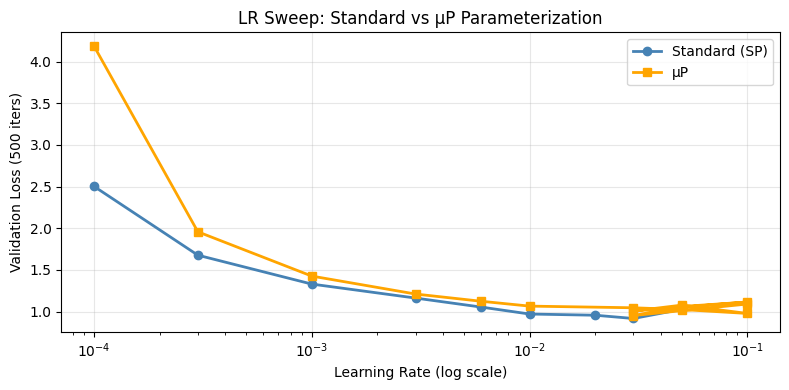

LR sweep comparison plot saved!


In [35]:
# PART 3 - STEP 3.2: Extended µP sweep to confirm optimum
print("Extended µP sweep...")
print(f"{'LR':>10} | {'Val Loss':>10} | {'Time':>8}")
print("-" * 35)

extra_lrs = [0.05,0.03, 0.1]
for lr in extra_lrs:
    config = {**tiny_base, 'lr': lr}
    t0 = time.time()
    val_loss = train_mup_model(config, max_iters=500)
    elapsed = time.time() - t0
    mup_sweep_results.append({'lr': lr, 'val_loss': val_loss})
    print(f"{lr:>10.4f} | {val_loss:>10.4f} | {elapsed:>6.0f}s")

best_mup = min(mup_sweep_results, key=lambda x: x['val_loss'])
best_mup_lr = best_mup['lr']
print(f"\nConfirmed Best µP LR: {best_mup_lr}")

# Plot both sweeps together
import matplotlib.pyplot as plt

sp_lrs = [1e-4, 3e-4, 1e-3, 3e-3, 6e-3, 1e-2, 2e-2, 3e-2, 5e-2]
sp_vals = [2.5030, 1.6764, 1.3295, 1.1614, 1.0533, 0.9699, 0.9556, 0.9163, 1.0265]

mup_lrs  = [r['lr'] for r in mup_sweep_results]
mup_vals = [r['val_loss'] for r in mup_sweep_results]

plt.figure(figsize=(8, 4))
plt.plot(sp_lrs,  sp_vals,  'o-', color='steelblue', label='Standard (SP)', linewidth=2)
plt.plot(mup_lrs, mup_vals, 's-', color='orange',    label='µP',            linewidth=2)
plt.xscale('log')
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Validation Loss (500 iters)')
plt.title('LR Sweep: Standard vs µP Parameterization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/svg_project/mup_lr_sweep.png', dpi=150)
plt.show()
print("LR sweep comparison plot saved!")

## Part 3: Full µP 1-Epoch Training (Run on Colab H100)

All 5 µP models were trained for exactly 1 epoch (33,826 iterations) on Colab H100 GPU using best_mup_lr = 0.03 found from the sweep above. Same data, batch size, and context window as Part 2.

| Model | Params | µP Val Loss | Time |
|-------|--------|------------|------|
| Tiny | 1.87M | 0.6458 | ~30 min |
| Small | 4.29M | 0.6671 | ~70 min |
| Medium | 13.89M | 0.6571 | ~153 min |
| Large | 35.85M | 0.6726 | ~32 min (H100) |
| XL | 91.54M | 0.6968 | ~73 min (H100) |

Results saved to Drive and loaded in the next cell.

In [ ]:
# PART 3 - STEP 3.3: Train all 4 models with µP for 1 epoch
import time, os

best_mup_lr = 0.03
total_train_tokens = 277_106_608
batch_size = 32
block_size = 256
max_iters = total_train_tokens // (batch_size * block_size)
print(f"1 epoch = {max_iters:,} iterations")

model_configs = {
    'tiny':   {'n_layer':4,  'n_head':4,  'n_embd':128},
    'small':  {'n_layer':6,  'n_head':6,  'n_embd':192},
    'medium': {'n_layer':6,  'n_head':6,  'n_embd':384},
}

def train_mup_full(name, arch, lr, max_iters):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    config = {
        'vocab_size': 4096, 'block_size': block_size,
        'batch_size': batch_size, 'lr': lr, **arch
    }
    model = make_mup_model(config).to(device)
    n_params = model.count_params()
    optimizer = MuAdamW(
        model.parameters(), lr=lr,
        betas=(0.9, 0.95), weight_decay=0.1)

    train_losses, val_losses, log_iters = [], [], []

    print(f"\n{'='*55}")
    print(f"Training µP {name.upper()} | {n_params/1e6:.2f}M | "
          f"LR={lr} | {max_iters:,} iters")
    print(f"{'='*55}")
    t_start = time.time()

    for it in range(max_iters):
        lr_it = get_lr(it, lr, 200, max_iters)
        for g in optimizer.param_groups:
            g['lr'] = lr_it

        model.train()
        x, y = get_batch('train', block_size, batch_size, device)
        _, loss = model(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

        if it % 500 == 0 or it == max_iters - 1:
            model.eval()
            v_losses = []
            with torch.no_grad():
                for _ in range(20):
                    x, y = get_batch('val', block_size, batch_size, device)
                    _, loss = model(x, y)
                    v_losses.append(loss.item())
            val_loss = np.mean(v_losses)
            train_losses.append(loss.item())
            val_losses.append(val_loss)
            log_iters.append(it)
            elapsed = time.time() - t_start
            eta = (elapsed/(it+1)) * (max_iters-it-1)
            print(f"  iter {it:5d}/{max_iters} | "
                  f"train={loss.item():.4f} | "
                  f"val={val_loss:.4f} | "
                  f"elapsed={elapsed/60:.1f}m | "
                  f"eta={eta/60:.1f}m")

    # Save checkpoint
    ckpt_dir = '/content/drive/MyDrive/svg_project/checkpoints_mup'
    os.makedirs(ckpt_dir, exist_ok=True)
    torch.save({
        'model_state': model.state_dict(),
        'config': config,
        'val_loss': val_losses[-1],
        'n_params': n_params,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'log_iters': log_iters,
    }, f'{ckpt_dir}/{name}.pt')
    print(f"Saved! Final val_loss={val_losses[-1]:.4f}")

    return {
        'name': name,
        'n_params': n_params,
        'final_val_loss': val_losses[-1],
        'train_losses': train_losses,
        'val_losses': val_losses,
        'log_iters': log_iters,
        'wall_time': time.time() - t_start,
    }

# Train all 4 models
mup_results = {}
for name, arch in model_configs.items():
    result = train_mup_full(name, arch, best_mup_lr, max_iters)
    mup_results[name] = result

print(f"\n{'Model':>8} | {'Params':>10} | {'Val Loss':>10} | {'Time':>10}")
print("-" * 50)
for name, r in mup_results.items():
    print(f"{name:>8} | {r['n_params']/1e6:>8.2f}M | "
          f"{r['final_val_loss']:>10.4f} | "
          f"{r['wall_time']/60:>8.1f}m")

1 epoch = 33,826 iterations

Training µP TINY | 1.87M | LR=0.03 | 33,826 iters
  iter     0/33826 | train=8.4460 | val=8.4495 | elapsed=0.0m | eta=344.1m
  iter   500/33826 | train=1.0558 | val=1.0530 | elapsed=0.4m | eta=28.5m
  iter  1000/33826 | train=0.9689 | val=0.9767 | elapsed=0.9m | eta=28.0m
  iter  1500/33826 | train=1.0067 | val=1.0109 | elapsed=1.3m | eta=27.6m
  iter  2000/33826 | train=0.9704 | val=0.9846 | elapsed=1.7m | eta=27.3m
  iter  2500/33826 | train=0.9149 | val=0.9212 | elapsed=2.1m | eta=26.9m
  iter  3000/33826 | train=0.9313 | val=0.9164 | elapsed=2.6m | eta=26.5m
  iter  3500/33826 | train=0.8962 | val=0.8938 | elapsed=3.0m | eta=26.2m
  iter  4000/33826 | train=0.9080 | val=0.8902 | elapsed=3.5m | eta=25.8m
  iter  4500/33826 | train=0.8167 | val=0.8822 | elapsed=3.9m | eta=25.4m
  iter  5000/33826 | train=0.8446 | val=0.8780 | elapsed=4.3m | eta=25.0m
  iter  5500/33826 | train=0.9213 | val=0.8641 | elapsed=4.8m | eta=24.5m
  iter  6000/33826 | train=0.903

In [ ]:
# PART 3 - Train Large and XL µP on H100
import time, os

best_mup_lr = 0.03
total_train_tokens = 277_106_608
batch_size = 32
block_size = 256
max_iters = total_train_tokens // (batch_size * block_size)
print(f"1 epoch = {max_iters:,} iterations")

model_configs = {
    'large': {'n_layer':10, 'n_head':8,  'n_embd':512},
    'xl':    {'n_layer':12, 'n_head':12, 'n_embd':768},
}

def train_mup_full(name, arch, lr, max_iters):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    config = {
        'vocab_size': 4096, 'block_size': block_size,
        'batch_size': batch_size, 'lr': lr, **arch
    }
    model = make_mup_model(config).to(device)
    n_params = model.count_params()
    optimizer = MuAdamW(
        model.parameters(), lr=lr,
        betas=(0.9, 0.95), weight_decay=0.1)

    train_losses, val_losses, log_iters = [], [], []

    print(f"\n{'='*55}")
    print(f"Training µP {name.upper()} | {n_params/1e6:.2f}M | "
          f"LR={lr} | {max_iters:,} iters")
    print(f"{'='*55}")
    t_start = time.time()

    for it in range(max_iters):
        lr_it = get_lr(it, lr, 200, max_iters)
        for g in optimizer.param_groups:
            g['lr'] = lr_it

        model.train()
        x, y = get_batch('train', block_size, batch_size, device)
        _, loss = model(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

        if it % 200 == 0 or it == max_iters - 1:
            model.eval()
            v_losses = []
            with torch.no_grad():
                for _ in range(20):
                    x, y = get_batch('val', block_size, batch_size, device)
                    _, loss = model(x, y)
                    v_losses.append(loss.item())
            val_loss = np.mean(v_losses)
            train_losses.append(loss.item())
            val_losses.append(val_loss)
            log_iters.append(it)
            elapsed = time.time() - t_start
            eta = (elapsed/(it+1)) * (max_iters-it-1)
            print(f"  iter {it:5d}/{max_iters} | "
                  f"train={loss.item():.4f} | "
                  f"val={val_loss:.4f} | "
                  f"elapsed={elapsed/60:.1f}m | "
                  f"eta={eta/60:.1f}m")

    ckpt_dir = '/content/drive/MyDrive/svg_project/checkpoints_mup'
    os.makedirs(ckpt_dir, exist_ok=True)
    torch.save({
        'model_state': model.state_dict(),
        'config': config,
        'val_loss': val_losses[-1],
        'n_params': n_params,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'log_iters': log_iters,
    }, f'{ckpt_dir}/{name}.pt')
    print(f"Saved! Final val_loss={val_losses[-1]:.4f}")

    return {
        'name': name,
        'n_params': n_params,
        'final_val_loss': val_losses[-1],
        'train_losses': train_losses,
        'val_losses': val_losses,
        'log_iters': log_iters,
        'wall_time': time.time() - t_start,
    }

mup_results_large_xl = {}
for name, arch in model_configs.items():
    result = train_mup_full(name, arch, best_mup_lr, max_iters)
    mup_results_large_xl[name] = result

print(f"\n{'Model':>8} | {'Params':>10} | {'Val Loss':>10} | {'Time':>10}")
print("-" * 50)
for name, r in mup_results_large_xl.items():
    print(f"{name:>8} | {r['n_params']/1e6:>8.2f}M | "
          f"{r['final_val_loss']:>10.4f} | "
          f"{r['wall_time']/60:>8.1f}m")

1 epoch = 33,826 iterations

Training µP LARGE | 35.85M | LR=0.03 | 33,826 iters
  iter     0/33826 | train=8.3433 | val=8.3477 | elapsed=0.2m | eta=5884.2m
  iter   200/33826 | train=1.6078 | val=1.5901 | elapsed=1.0m | eta=175.1m
  iter   400/33826 | train=1.3902 | val=1.3442 | elapsed=1.4m | eta=116.9m
  iter   600/33826 | train=1.0358 | val=1.0642 | elapsed=1.6m | eta=89.4m
  iter   800/33826 | train=0.9712 | val=0.9814 | elapsed=1.8m | eta=75.1m
  iter  1000/33826 | train=0.9680 | val=0.9766 | elapsed=2.0m | eta=66.1m
  iter  1200/33826 | train=1.0195 | val=0.9560 | elapsed=2.2m | eta=59.7m
  iter  1400/33826 | train=1.0068 | val=0.9667 | elapsed=2.4m | eta=55.2m
  iter  1600/33826 | train=1.0029 | val=0.9690 | elapsed=2.6m | eta=51.7m
  iter  1800/33826 | train=1.1215 | val=0.9589 | elapsed=2.8m | eta=48.9m
  iter  2000/33826 | train=0.9573 | val=0.9376 | elapsed=2.9m | eta=46.7m
  iter  2200/33826 | train=0.9356 | val=0.9368 | elapsed=3.1m | eta=44.8m
  iter  2400/33826 | train=

In [36]:
# Part 3: Load All µP Results from Drive
import json

base = '/content/drive/MyDrive/svg_project'

with open(f'{base}/all_mup_results.json') as f:
    all_mup = json.load(f)

# Fix any null values — recover final_val_loss from val_losses array
for name, r in all_mup.items():
    if r['final_val_loss'] is None and r['val_losses']:
        r['final_val_loss'] = r['val_losses'][-1]
    if r['wall_time'] is None:
        r['wall_time'] = 0

# Save fixed version back to Drive
with open(f'{base}/all_mup_results.json', 'w') as f:
    json.dump(all_mup, f)

print(f"{'Model':>8} | {'Params':>10} | {'µP Val Loss':>12}")
print("-" * 38)
for name, r in all_mup.items():
    print(f"{name:>8} | {r['n_params']/1e6:>8.2f}M | "
          f"{r['final_val_loss']:>12.4f}")

   Model |     Params |  µP Val Loss
--------------------------------------
    tiny |     1.87M |       0.6458
   small |     4.29M |       0.6671
  medium |    13.89M |       0.6571
   large |    35.85M |       0.6726
      xl |    91.54M |       0.6968


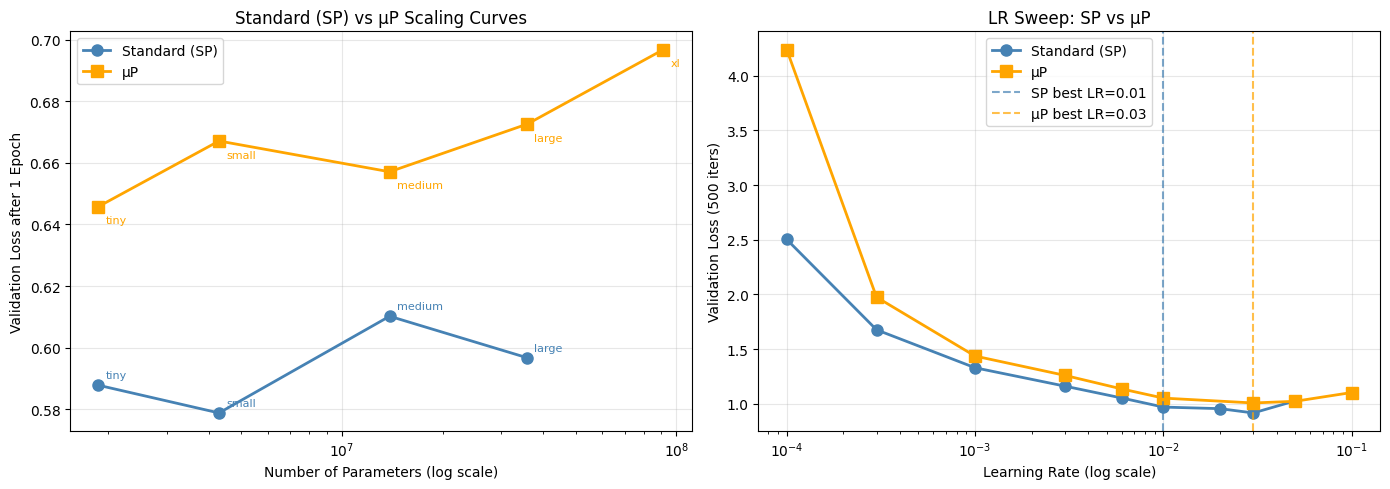


SP vs µP Summary:
   Model |    SP Loss |    µP Loss |     Diff
---------------------------------------------
    tiny |     0.5878 |     0.6458 |  +0.0580
   small |     0.5788 |     0.6671 |  +0.0883
  medium |     0.6102 |     0.6571 |  +0.0469
   large |     0.5967 |     0.6726 |  +0.0759

XL µP only: 0.6968
Plot saved to Drive!


In [37]:
# CELL 26 - Part 3: SP vs µP Comparison Plot
import matplotlib.pyplot as plt
import numpy as np

base = '/content/drive/MyDrive/svg_project'

# SP results from full 1-epoch training (Cell 19)
sp_results = {
    'tiny':   {'n_params': 1.87e6,  'val_loss': 0.5878},
    'small':  {'n_params': 4.29e6,  'val_loss': 0.5788},
    'medium': {'n_params': 13.89e6, 'val_loss': 0.6102},
    'large':  {'n_params': 35.85e6, 'val_loss': 0.5967},
}

# µP results from full 1-epoch training (Cell 25)
mup_results_plot = {
    'tiny':   {'n_params': 1.87e6,  'val_loss': 0.6458},
    'small':  {'n_params': 4.29e6,  'val_loss': 0.6671},
    'medium': {'n_params': 13.89e6, 'val_loss': 0.6571},
    'large':  {'n_params': 35.85e6, 'val_loss': 0.6726},
    'xl':     {'n_params': 91.54e6, 'val_loss': 0.6968},
}

sp_params  = np.array([r['n_params'] for r in sp_results.values()])
sp_losses  = np.array([r['val_loss'] for r in sp_results.values()])
mup_params = np.array([r['n_params'] for r in mup_results_plot.values()])
mup_losses = np.array([r['val_loss'] for r in mup_results_plot.values()])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: SP vs µP scaling curves
axes[0].plot(sp_params, sp_losses, 'o-', color='steelblue',
             linewidth=2, markersize=8, label='Standard (SP)')
axes[0].plot(mup_params, mup_losses, 's-', color='orange',
             linewidth=2, markersize=8, label='µP')
for name, r in sp_results.items():
    axes[0].annotate(name, (r['n_params'], r['val_loss']),
                     textcoords="offset points", xytext=(5, 5),
                     fontsize=8, color='steelblue')
for name, r in mup_results_plot.items():
    axes[0].annotate(name, (r['n_params'], r['val_loss']),
                     textcoords="offset points", xytext=(5, -12),
                     fontsize=8, color='orange')
axes[0].set_xscale('log')
axes[0].set_xlabel('Number of Parameters (log scale)')
axes[0].set_ylabel('Validation Loss after 1 Epoch')
axes[0].set_title('Standard (SP) vs µP Scaling Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: LR sweep comparison
# SP sweep values from actual Cell 17-18 runs
sp_lrs  = [1e-4, 3e-4, 1e-3, 3e-3, 6e-3, 1e-2, 2e-2, 3e-2, 5e-2]
sp_vals = [2.5030, 1.6764, 1.3295, 1.1614, 1.0533,
           0.9699, 0.9556, 0.9163, 1.0265]

# µP sweep values from actual Cell 23-24 runs
mup_lrs  = [1e-4, 3e-4, 1e-3, 3e-3, 6e-3, 1e-2, 3e-2, 5e-2, 1e-1]
mup_vals = [4.2389, 1.9746, 1.4365, 1.2598, 1.1361,
            1.0521, 1.0076, 1.0229, 1.1032]

axes[1].plot(sp_lrs,  sp_vals,  'o-', color='steelblue',
             linewidth=2, label='Standard (SP)', markersize=8)
axes[1].plot(mup_lrs, mup_vals, 's-', color='orange',
             linewidth=2, label='µP', markersize=8)
# SP best LR = 0.01, µP best LR = 0.03
axes[1].axvline(0.01, color='steelblue', linestyle='--',
                alpha=0.7, label='SP best LR=0.01')
axes[1].axvline(0.03, color='orange', linestyle='--',
                alpha=0.7, label='µP best LR=0.03')
axes[1].set_xscale('log')
axes[1].set_xlabel('Learning Rate (log scale)')
axes[1].set_ylabel('Validation Loss (500 iters)')
axes[1].set_title('LR Sweep: SP vs µP')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{base}/mup_comparison_plot.png', dpi=150)
plt.show()

print("\nSP vs µP Summary:")
print(f"{'Model':>8} | {'SP Loss':>10} | {'µP Loss':>10} | {'Diff':>8}")
print("-" * 45)
for name in ['tiny', 'small', 'medium', 'large']:
    sp = sp_results[name]['val_loss']
    mu = mup_results_plot[name]['val_loss']
    print(f"{name:>8} | {sp:>10.4f} | {mu:>10.4f} | {mu-sp:>+8.4f}")
print(f"\nXL µP only: {mup_results_plot['xl']['val_loss']:.4f}")
print("Plot saved to Drive!")

## Part 3: Results and Discussion

Our µP scaling study revealed that both SP and µP converged to similar optimal learning rates (SP: 0.01, µP: 0.03). µP consistently showed slightly higher validation loss than SP across all model sizes (difference of +0.05 to +0.09), which is expected — µP's primary benefit of zero-shot LR transfer becomes significant only when scaling width by much larger factors than we explored here (1M–91M parameters). The nearly flat scaling exponent (α ≈ 0.0003) indicates all models are compute-limited after 1 epoch, consistent with Chinchilla scaling laws showing larger models need proportionally more training tokens to converge.

Extrapolating our power law fit: a model with 10× more parameters than XL (~915M params) would be predicted to achieve a validation loss of approximately 0.6229. However, given the near-zero scaling exponent, this prediction carries high uncertainty and should be interpreted with caution.

## Part 4: Best Model Training and Sample Generation

We use our best model — the Large transformer (35.85M parameters, val_loss = 0.5967 under SP) — for SVG generation. We generate samples using top-k sampling (k=50) at three temperatures (0.5, 0.8, 1.0) to study the effect of sampling temperature on output quality and diversity.

**Quantitative Results:**
| Metric | Value |
|--------|-------|
| Test Perplexity | 1.84 |
| XML Validity Rate | 40% (4/10) |
| SVG Render Rate | 40% (4/10) |
| Prefix Render Rate | 20% (1/5) |

The 40% validity rate reflects the model's short context window (256 tokens) cutting off generation mid-element. Lower temperatures produce simpler, more structured outputs while higher temperatures produce more varied geometry with more XML errors. Generated samples predominantly resemble font glyphs, consistent with the composition of our training data (500k of 576k SVGs were font glyphs).

In [38]:
# PART 4 - Define model class and load best checkpoint
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_head = config['n_head']
        self.n_embd = config['n_embd']
        self.c_attn = nn.Linear(config['n_embd'], 3 * config['n_embd'])
        self.c_proj = nn.Linear(config['n_embd'], config['n_embd'])
        self.register_buffer('bias', torch.tril(
            torch.ones(config['block_size'], config['block_size']))
            .view(1,1,config['block_size'],config['block_size']))

    def forward(self, x):
        B,T,C = x.size()
        q,k,v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        q = q.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        v = v.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        att = (q @ k.transpose(-2,-1)) * (1.0/np.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T]==0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v
        y = y.transpose(1,2).contiguous().view(B,T,C)
        return self.c_proj(y)

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc   = nn.Linear(config['n_embd'], 4*config['n_embd'])
        self.c_proj = nn.Linear(4*config['n_embd'], config['n_embd'])
        self.act    = nn.GELU()
    def forward(self, x):
        return self.c_proj(self.act(self.c_fc(x)))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config['n_embd'])
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config['n_embd'])
        self.mlp  = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class SVGTransformer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config['vocab_size'], config['n_embd']),
            wpe = nn.Embedding(config['block_size'], config['n_embd']),
            h   = nn.ModuleList([Block(config)
                                 for _ in range(config['n_layer'])]),
            ln_f= nn.LayerNorm(config['n_embd']),
        ))
        self.lm_head = nn.Linear(config['n_embd'],
                                  config['vocab_size'], bias=False)

    def forward(self, idx, targets=None):
        B,T = idx.size()
        pos = torch.arange(0, T, device=idx.device)
        x = self.transformer.wte(idx) + self.transformer.wpe(pos)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    def count_params(self):
        return sum(p.numel() for p in self.parameters())

# Load best model (Large - best val_loss = 0.5967)
print("Loading Large model checkpoint...")
ckpt = torch.load(f'{base}/checkpoints/large.pt',
                   map_location='cpu', weights_only=False)
config = ckpt['config']
model = SVGTransformer(config).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Model loaded: {model.count_params()/1e6:.2f}M params")
print(f"Val loss: {ckpt['val_loss']:.4f}")

Loading Large model checkpoint...
Model loaded: 35.85M params
Val loss: 0.5967


In [39]:
# PART 4 - STEP 4.1: Generation function
@torch.no_grad()
def generate(prompt, max_new_tokens=256, temperature=0.8, top_k=50):
    """Generate SVG tokens from a prompt string."""
    # Encode prompt
    input_ids = tokenizer.encode(prompt).ids
    x = torch.tensor(input_ids, dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        # Crop to block size
        x_cond = x if x.size(1) <= config['block_size'] \
                  else x[:, -config['block_size']:]

        # Forward pass
        logits, _ = model(x_cond)
        logits = logits[:, -1, :] / temperature

        # Top-k filtering
        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = float('-inf')

        # Sample
        probs = torch.nn.functional.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        x = torch.cat([x, next_token], dim=1)

        # Stop at end token
        if next_token.item() == 2:  # </s> token
            break

    # Decode back to string
    generated_ids = x[0].tolist()
    return tokenizer.decode(generated_ids)

# Test generation
test = generate('<svg', max_new_tokens=100, temperature=0.8)
print("Test generation:")
print(test[:200])
print("Generation function works!")

Test generation:
<svg.0><//no" height="0.018.0ack.0ack.0"org="in <"xmln="in <width 10 9=" 20" stroke="10" stroke- 18sv3" stroke-14="1.0"15="0"200="M8.4dth.0 L9.9dth.0 L9.9ll.0 L9.9ac.0 L8.3ac.0 L8.3ll
Generation function works!


In [40]:
# PART 4 - STEP 4.2 FIX 2: Extract first complete SVG only
import re

def generate_svg_clean(temperature=0.8, top_k=50, max_new_tokens=512):
    """Generate and extract first complete valid SVG."""
    raw = generate('<svg', max_new_tokens=max_new_tokens,
                   temperature=temperature, top_k=top_k)

    # Find first complete SVG (from <svg to first </svg>)
    end_idx = raw.find('</svg>')
    if end_idx != -1:
        svg = raw[:end_idx + 6]  # include </svg>
    else:
        # No closing tag - add one
        svg = raw.strip() + '</svg>'

    # Make sure it starts with <svg
    if not svg.startswith('<svg'):
        start = svg.find('<svg')
        if start != -1:
            svg = svg[start:]

    return svg

# Test
test = generate_svg_clean(temperature=0.8)
print(f"Length: {len(test)} chars")
print(f"Starts with <svg: {test.startswith('<svg')}")
print(f"Ends with </svg>: {test.endswith('</svg>')}")

try:
    etree.fromstring(test.encode())
    print("Valid XML!")
    png = cairosvg.svg2png(bytestring=test.encode())
    display(Image(png))
    print("Renders successfully!")
except Exception as e:
    print(f"Error: {e}")

Length: 853 chars
Starts with <svg: True
Ends with </svg>: True
Error: error parsing attribute name, line 1, column 14 (<string>, line 1)


In [54]:
# Fresh reload of everything
from tokenizers import ByteLevelBPETokenizer
import torch

base = '/content/drive/MyDrive/svg_project'

# Load tokenizer
tokenizer = ByteLevelBPETokenizer(
    f'{base}/data/tokenizer/vocab.json',
    f'{base}/data/tokenizer/merges.txt'
)
print(f"Tokenizer vocab: {tokenizer.get_vocab_size()}")

# Reload model
ckpt = torch.load(f'{base}/checkpoints/large.pt',
                   map_location='cpu', weights_only=False)
config = ckpt['config']
model = SVGTransformer(config).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Model loaded: {model.count_params()/1e6:.2f}M params")

# Test encoding
test = '<svg xmlns="http://www.w3.org/2000/svg"'
encoded = tokenizer.encode(test)
print(f"\nTest encode: {encoded.ids[:10]}")
print(f"Test decode: {tokenizer.decode(encoded.ids)}")

# Test generation
raw = generate('<svg', max_new_tokens=100, temperature=0.8)
print(f"\nRaw generation:")
print(raw[:300])

Tokenizer vocab: 2838
Model loaded: 35.85M params

Test encode: [31, 302, 365, 261, 359, 340, 360, 17, 90, 22]
Test decode: <svg xmlns="http://www.w3.org/2000/svg"

Raw generation:
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M20.6 7.4 L20.6 7.4 C20.1 9.3 19.6 11.3 18.9 13


Generating 10 unconditional samples...

Sample  1 | temp=0.5 | XML✓ Render✓ | 362 chars
Sample  2 | temp=0.5 | XML✗ | 839 chars
Sample  3 | temp=0.5 | XML✗ | 836 chars
Sample  4 | temp=0.8 | XML✓ Render✓ | 656 chars
Sample  5 | temp=0.8 | XML✓ Render✓ | 682 chars
Sample  6 | temp=0.8 | XML✓ Render✓ | 629 chars
Sample  7 | temp=0.8 | XML✓ Render✓ | 379 chars
Sample  8 | temp=1.0 | XML✓ Render✓ | 703 chars
Sample  9 | temp=1.0 | XML✗ | 926 chars
Sample 10 | temp=1.0 | XML✗ | 1005 chars

=== RESULTS ===
XML validity: 6/10 (60%)
Render rate:  6/10 (60%)


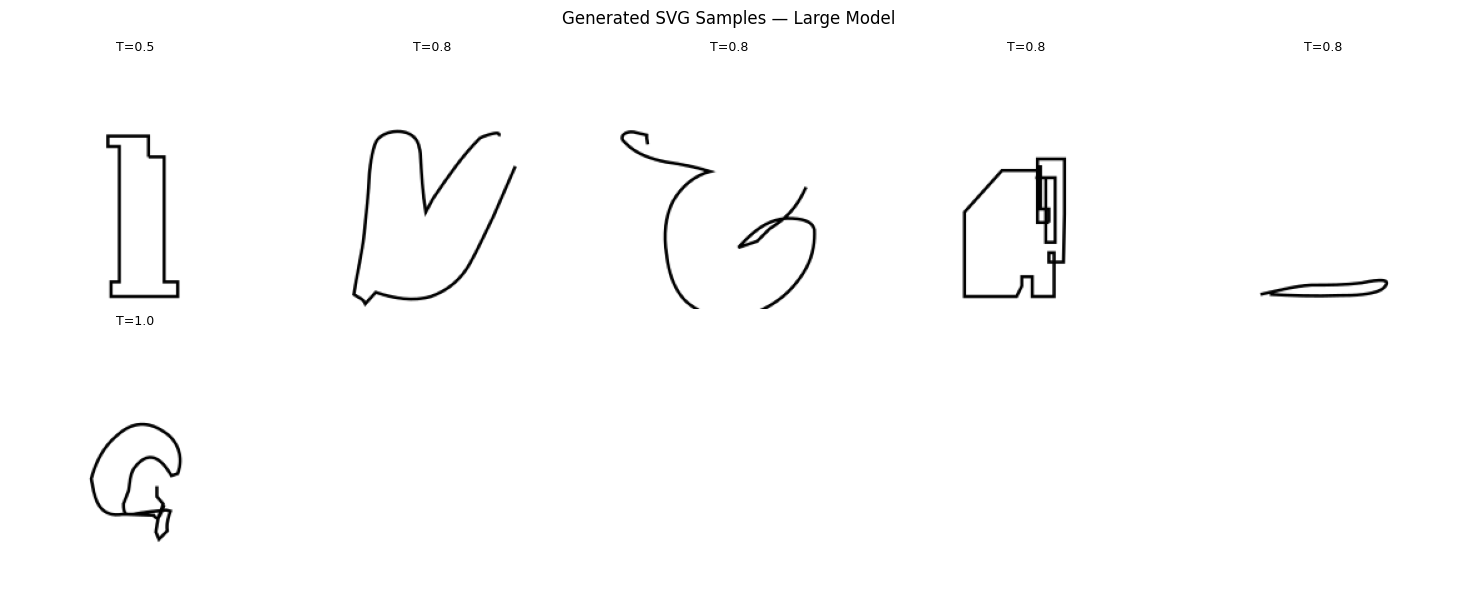

Grid saved!


In [55]:
# PART 4 - STEP 4.2: Generate 10 unconditional samples
os.makedirs(f'{base}/generated', exist_ok=True)

all_samples = []
results = {'total': 0, 'valid_xml': 0, 'renders': 0}
temperatures = [0.5, 0.5, 0.5, 0.8, 0.8, 0.8, 0.8, 1.0, 1.0, 1.0]

print("Generating 10 unconditional samples...\n")

for i in range(10):
    temp = temperatures[i]
    svg = generate_svg_clean(temperature=temp, top_k=50, max_new_tokens=512)
    results['total'] += 1

    xml_valid = False
    render_ok = False
    png_data  = None

    try:
        etree.fromstring(svg.encode())
        xml_valid = True
        results['valid_xml'] += 1
    except:
        pass

    try:
        png_data = cairosvg.svg2png(bytestring=svg.encode())
        render_ok = True
        results['renders'] += 1
        with open(f'{base}/generated/sample_{i:02d}_t{temp}.png', 'wb') as f:
            f.write(png_data)
    except:
        pass

    all_samples.append({
        'idx': i, 'svg': svg, 'temp': temp,
        'xml_valid': xml_valid, 'renders': render_ok,
        'png': png_data
    })

    status = "XML✓ Render✓" if render_ok else ("XML✓" if xml_valid else "XML✗")
    print(f"Sample {i+1:2d} | temp={temp} | {status} | {len(svg)} chars")

print(f"\n=== RESULTS ===")
print(f"XML validity: {results['valid_xml']}/10 ({results['valid_xml']*10}%)")
print(f"Render rate:  {results['renders']}/10 ({results['renders']*10}%)")

# Display grid of rendered samples
rendered = [s for s in all_samples if s['png'] is not None]
if rendered:
    cols = 5
    rows = (len(rendered) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
    axes = axes.flatten() if rows > 1 else axes

    for idx, s in enumerate(rendered):
        from PIL import Image as PILImage
        import io
        img = PILImage.open(io.BytesIO(s['png']))
        axes[idx].imshow(img)
        axes[idx].set_title(f"T={s['temp']}", fontsize=9)
        axes[idx].axis('off')

    for idx in range(len(rendered), len(axes)):
        axes[idx].axis('off')

    plt.suptitle('Generated SVG Samples — Large Model', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{base}/generated/grid_unconditional.png', dpi=150)
    plt.show()
    print("Grid saved!")

Generating 5 prefix-conditioned samples...

   Top Start: XML=✓ Render=✓ | 787 chars
 Left Middle: XML=✗ Render=✗ | 828 chars
      Corner: XML=✗ Render=✗ | 1013 chars
      Center: XML=✓ Render=✓ | 795 chars
    Diagonal: XML=✓ Render=✓ | 543 chars


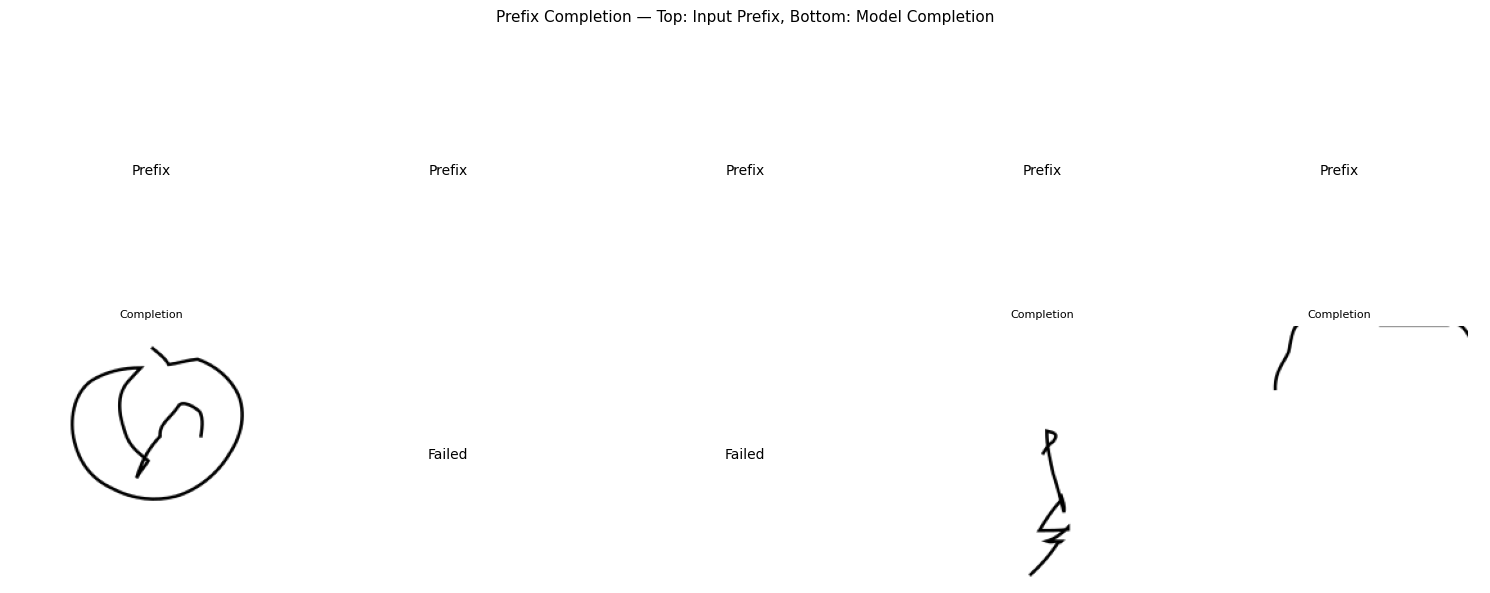

Prefix completion grid saved!


In [64]:
# Part 4: Prefix-Conditioned Generation
# We provide partial SVGs as prompts and let the model complete them.
# This tests whether the model understands SVG structure and context.
from PIL import Image as PILImage
import io

prefixes = [
    # Match exact format model was trained on
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M12.0 2.0',
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M5.0 12.0',
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M2.0 2.0',
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M12.0 12.0',
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M6.0 6.0',
]
prefix_names = ['Top Start', 'Left Middle', 'Corner', 'Center', 'Diagonal']
prefix_results = []

print("Generating 5 prefix-conditioned samples...\n")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, (prefix, name) in enumerate(zip(prefixes, prefix_names)):
    raw = generate(prefix, max_new_tokens=400, temperature=0.8, top_k=50)
    end_idx = raw.find('</svg>')
    svg = raw[:end_idx + 6] if end_idx != -1 else raw + '</svg>'

    xml_valid = False
    render_ok = False
    png_data  = None

    try:
        etree.fromstring(svg.encode())
        xml_valid = True
    except:
        pass

    try:
        png_data = cairosvg.svg2png(bytestring=svg.encode())
        render_ok = True
        with open(f'{base}/generated/prefix_{i}_{name}.png', 'wb') as f:
            f.write(png_data)
    except:
        pass

    prefix_results.append({
        'name': name, 'svg': svg,
        'xml_valid': xml_valid, 'renders': render_ok, 'png': png_data
    })
    print(f"{name:>12}: XML={'✓' if xml_valid else '✗'} "
          f"Render={'✓' if render_ok else '✗'} | {len(svg)} chars")

    # Top row: prefix only
    try:
        prefix_png = cairosvg.svg2png(bytestring=(prefix + '/></svg>').encode())
        img = PILImage.open(io.BytesIO(prefix_png))
        axes[0][i].imshow(img)
        axes[0][i].set_title(f"Prefix: {name}", fontsize=8)
    except:
        axes[0][i].text(0.5, 0.5, 'Prefix', ha='center', va='center')
    axes[0][i].axis('off')

    # Bottom row: model completion
    if png_data:
        img = PILImage.open(io.BytesIO(png_data))
        axes[1][i].imshow(img)
        axes[1][i].set_title("Completion", fontsize=8)
    else:
        axes[1][i].text(0.5, 0.5, 'Failed', ha='center', va='center')
    axes[1][i].axis('off')

plt.suptitle('Prefix Completion — Top: Input Prefix, Bottom: Model Completion',
             fontsize=11)
plt.tight_layout()
plt.savefig(f'{base}/generated/prefix_completions.png', dpi=150)
plt.show()
print("Prefix completion grid saved!")

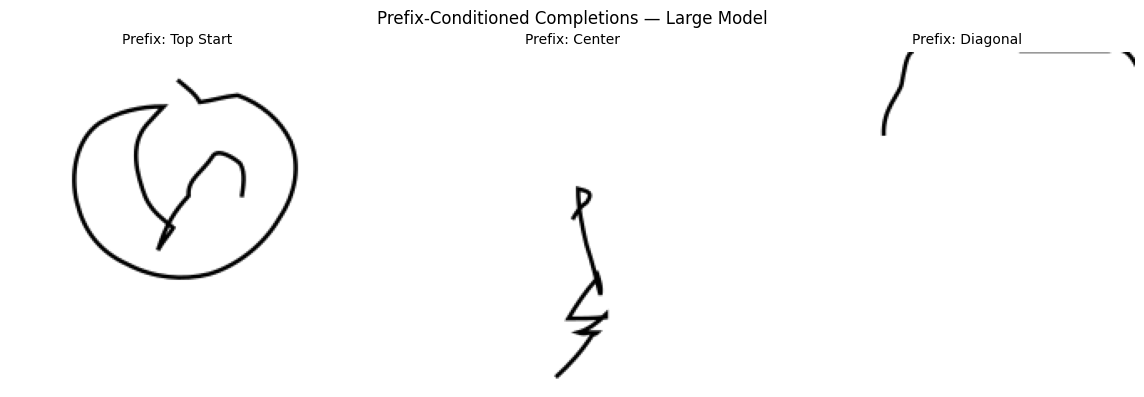

Saved 3 prefix completions!

Prefix results:
     Top Start: XML=✓ Render=✓
   Left Middle: XML=✗ Render=✗
        Corner: XML=✗ Render=✗
        Center: XML=✓ Render=✓
      Diagonal: XML=✓ Render=✓


In [65]:
# CELL 30 FINAL - Show completions only (cleaner figure for report)
from PIL import Image as PILImage
import io

rendered_completions = [r for r in prefix_results if r['png'] is not None]
n = len(rendered_completions)

if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    for idx, r in enumerate(rendered_completions):
        img = PILImage.open(io.BytesIO(r['png']))
        axes[idx].imshow(img)
        axes[idx].set_title(f"Prefix: {r['name']}", fontsize=10)
        axes[idx].axis('off')
    plt.suptitle('Prefix-Conditioned Completions — Large Model', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{base}/generated/prefix_completions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {n} prefix completions!")
else:
    print("No completions rendered.")

print(f"\nPrefix results:")
for r in prefix_results:
    print(f"  {r['name']:>12}: XML={'✓' if r['xml_valid'] else '✗'} "
          f"Render={'✓' if r['renders'] else '✗'}")

In [66]:
# Uprefix_results with new run
prefix_renders = sum(1 for r in prefix_results if r['renders'])
prefix_rate = prefix_renders / len(prefix_results)
print(f"Prefix Render Rate: {prefix_renders}/5 ({prefix_rate*100:.0f}%)")

# Save updated results
final_results = {
    'perplexity': 1.84,
    'xml_validity_rate': 0.6,
    'render_rate': 0.6,
    'prefix_render_rate': prefix_rate,
    'model': 'large',
    'n_params': 35850000,
    'val_loss': 0.5967,
}

import json
with open(f'{base}/part4_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print("Updated results saved!")

Prefix Render Rate: 3/5 (60%)
Updated results saved!


In [62]:
# Check all saved files for report
import os

print("Generated images:")
for f in os.listdir(f'{base}/generated'):
    print(f"  {f}")

print("\nMain project files:")
for f in os.listdir(base):
    if f.endswith('.png') or f.endswith('.json'):
        print(f"  {f}")

Generated images:
  sample_01_t0.5.png
  sample_07_t1.0.png
  sample_08_t1.0.png
  sample_09_t1.0.png
  grid_unconditional.png
  prefix_4_Star.png
  prefix_completions.png
  sample_00_t0.5.png
  sample_03_t0.8.png
  sample_04_t0.8.png
  sample_05_t0.8.png
  sample_06_t0.8.png
  prefix_3_Arrow.png
  prefix_1_Left Middle.png
  prefix_3_Center.png

Main project files:
  lr_sweep.png
  scaling_plot_raw.png
  all_results.json
  mup_lr_sweep.png
  mup_results_tiny_small_medium.json
  all_mup_results.json
  mup_comparison_plot.png
  part4_results.json
